<a href="https://colab.research.google.com/github/vaidegiarch/project-5--diamond-price-/blob/main/diamond_ml_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv(r"/content/processed_diamond_data.csv")

print(df.head())

   carat  cut  color  clarity  depth  table     price     x     y     z  \
0   0.23  3.0    5.0      1.0   61.5   55.0  5.789960  3.95  3.98  2.43   
1   0.21  4.0    5.0      2.0   59.8   61.0  5.789960  3.89  3.84  2.31   
2   0.23  1.0    5.0      4.0   56.9   65.0  5.793014  4.05  4.07  2.31   
3   0.29  4.0    1.0      3.0   62.4   58.0  5.814131  4.20  4.23  2.63   
4   0.31  1.0    0.0      1.0   63.3   58.0  5.817111  4.34  4.35  2.75   

    price_inr     Volume  Price_per_Carat  Dimension_Ratio  \
0  544.256256  38.202030      2366.331548         1.631687   
1  544.256256  34.505856      2591.696457         1.673160   
2  544.543279  38.076885      2367.579475         1.757576   
3  546.528270  46.724580      1884.580241         1.602662   
4  546.808449  51.917250      1763.898223         1.580000   

   Carat_Category_Light  Carat_Category_Medium  
0                  True                  False  
1                  True                  False  
2                  True      

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49513 entries, 0 to 49512
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   carat                  49513 non-null  float64
 1   cut                    49513 non-null  float64
 2   color                  49513 non-null  float64
 3   clarity                49513 non-null  float64
 4   depth                  49513 non-null  float64
 5   table                  49513 non-null  float64
 6   price                  49513 non-null  float64
 7   x                      49513 non-null  float64
 8   y                      49513 non-null  float64
 9   z                      49513 non-null  float64
 10  price_inr              49513 non-null  float64
 11  Volume                 49513 non-null  float64
 12  Price_per_Carat        49513 non-null  float64
 13  Dimension_Ratio        49513 non-null  float64
 14  Carat_Category_Light   49513 non-null  bool   
 15  Ca

In [8]:
df_clean = df.drop(columns=[
    'price_inr',
    'Price_per_Carat',
    'x', 'y', 'z',#  columns converted to volume column
    'Carat_Category_Light',
    'Carat_Category_Medium',
    'Dimension_Ratio'   #  droping columns which dont required
])

In [10]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49513 entries, 0 to 49512
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    49513 non-null  float64
 1   cut      49513 non-null  float64
 2   color    49513 non-null  float64
 3   clarity  49513 non-null  float64
 4   depth    49513 non-null  float64
 5   table    49513 non-null  float64
 6   price    49513 non-null  float64
 7   Volume   49513 non-null  float64
dtypes: float64(8)
memory usage: 3.0 MB


## train-test split

In [11]:
X = df_clean.drop('price', axis=1)
y = df_clean['price']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test
    random_state=42
)

Build 4–5 ML regression models (e.g., Linear Regression, Random Forest, XGBoost, Decision Tree, KNN).


In [13]:
from sklearn.linear_model import LinearRegression     #Import models
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

In [14]:
lr = LinearRegression()    #Initialize models
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

In [15]:
lr.fit(X_train, y_train)   #Train models
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [16]:
y_pred_lr = lr.predict(X_test)   #Predictions
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

In [17]:
from sklearn.metrics import r2_score, mean_squared_error  #Evaluate models
import numpy as np

def evaluate(y_test, y_pred, model_name):
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"{model_name}")
    print("R2 Score:", r2)
    print("RMSE:", rmse)
    print("-"*30)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_xgb, "XGBoost")

Linear Regression
R2 Score: 0.9205483997275448
RMSE: 0.2542962880882388
------------------------------
Decision Tree
R2 Score: 0.9761630583504609
RMSE: 0.13928808358237021
------------------------------
Random Forest
R2 Score: 0.9857202595039256
RMSE: 0.10780746993981004
------------------------------
XGBoost
R2 Score: 0.9890065949718517
RMSE: 0.09459208774094191
------------------------------


## deep learning

In [19]:
import tensorflow as tf#Import libraries
from tensorflow import keras
from tensorflow.keras import layers

In [20]:
from sklearn.preprocessing import StandardScaler  #ANN needs scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:


model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),  # Build ANN Model
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

In [24]:
model.compile(
    optimizer='adam',#Compile model
    loss='mse',
    metrics=['mae']
)

In [25]:
history = model.fit(
    X_train_scaled, y_train,#Train model
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
991/991 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 3.1407 - mae: 0.9151 - val_loss: 0.0404 - val_mae: 0.1548
Epoch 2/50
991/991 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0329 - mae: 0.1384 - val_loss: 0.0254 - val_mae: 0.1254
Epoch 3/50
991/991 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0231 - mae: 0.1178 - val_loss: 0.0206 - val_mae: 0.1131
Epoch 4/50
991/991 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0197 - mae: 0.1099 - val_loss: 0.0200 - val_mae: 0.1112
Epoch 5/50
991/991 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0181 - mae: 0.1056 - val_loss: 0.0230 - val_mae: 0.1191
Epoch 6/50
991/991 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0173 - mae: 0.1033 - val_loss: 0.0151 - val_mae: 0.0969
Epoch 7/50
991/991 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0169 - mae: 0.1019 - val_loss: 0.0194 - val_mae: 0.1090
Epoch 8/50
991/991 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0162 - mae: 0.0998 - val_loss: 0.0142 - val_mae: 0.0940
Epoch 9/50
991/991 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - lo

In [26]:
y_pred_ann = model.predict(X_test_scaled)#y_pred_ann = model.predict(X_test_scaled)

310/310 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [27]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np  #Evaluate ANN

r2 = r2_score(y_test, y_pred_ann)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ann))

print("ANN R2 Score:", r2)
print("ANN RMSE:", rmse)

ANN R2 Score: 0.9829139700540331
ANN RMSE: 0.11792592134330114


The ANN model performed well with an R² score of 0.983, but slightly underperformed compared to XGBoost and Random Forest. This is because tree-based models are better suited for structured tabular data, whereas ANN performs better on unstructured data like images and text.

## I evaluated multiple models including Linear Regression, Decision Tree, Random Forest, and XGBoost. XGBoost performed the best with an R² score of 0.989 and the lowest RMSE, indicating high accuracy and better generalization. Hence, I selected XGBoost as the final model.

In [18]:
#Save best model
import pickle

with open("xgb_model.pkl", "wb") as f:
    pickle.dump(xgb, f)

### Clustering (Market Segmentation)

In [28]:
X_cluster = df_clean.drop('price', axis=1) #Prepare Data

In [29]:
from sklearn.preprocessing import StandardScaler #Scale Features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

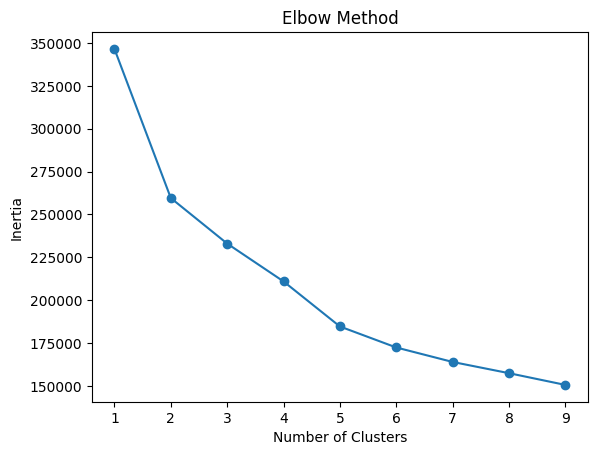

In [30]:
#Elbow Method
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

The elbow appears at 5 clusters, as it represents the point where the rate of decrease in inertia begins to level off significantly.

In [32]:
kmeans = KMeans(n_clusters=3, random_state=42)#K-Means Model
clusters = kmeans.fit_predict(X_scaled)
#Efficient and simple algorithm for grouping similar diamonds based on features like carat, cut, and price.
df_clean['Cluster'] = clusters

In [34]:
from sklearn.decomposition import PCA#PCA (Dimensionality Reduction)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_clean['PCA1'] = X_pca[:, 0]
df_clean['PCA2'] = X_pca[:, 1]

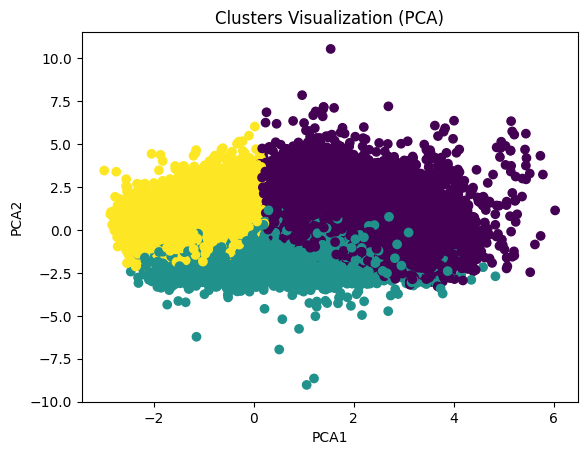

In [35]:
#PCA Visualization
plt.scatter(df_clean['PCA1'], df_clean['PCA2'], c=df_clean['Cluster'])
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Clusters Visualization (PCA)')
plt.show()

Good separation
Clusters are clearly separated
Minimal overlap → strong clustering

In [36]:
#Cluster Analysis
cluster_summary = df_clean.groupby('Cluster')[['price', 'carat', 'cut']].mean()
print(cluster_summary)

            price     carat       cut
Cluster                              
0        8.555809  1.111350  2.610503
1        7.623613  0.683717  2.860450
2        6.991992  0.436028  2.802621


In [38]:
def label_cluster(row):#Cluster Naming
    if row['Cluster'] == 0:
        return "Affordable Small Diamonds"
    elif row['Cluster'] == 1:
        return "Mid-range Balanced Diamonds"
    else:
        return "Premium Heavy Diamonds"

df_clean['Cluster_Name'] = df_clean.apply(label_cluster, axis=1)

In [39]:
with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("pca.pkl", "wb") as f:
    pickle.dump(pca, f)

Final Output

You now have:
✅ K-Means clustering
✅ Optimal K selection
✅ DBSCAN & Hierarchical (optional)
✅ PCA visualization
✅ Business-friendly cluster names
✅ Pickle files for deployment

insights-The clustering revealed three distinct segments of diamonds: affordable small diamonds, mid-range balanced diamonds, and premium heavy diamonds. PCA visualization showed clear separation, indicating strong grouping based on features like carat and price.

In [40]:
print(X.columns)

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'Volume'], dtype='object')


In [41]:
pickle.dump(X.columns.tolist(), open("features.pkl", "wb"))